# Transfer Learning and Distillation Experiments

This notebook implements VGG16 feature extraction and knowledge distillation using the tuned baseline architecture as the student.


In [9]:
import os
import sys
import json
import random
import pathlib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers

from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

KAGGLE_HELPERS_PARENT = "/kaggle/input/datasets/omosaad/helpers"
KAGGLE_HELPERS_DIR = "/kaggle/input/datasets/omosaad/helpers/helpers"

try:
    from helpers import data_utils, model_utils, training_utils
except ModuleNotFoundError:
    for p in [KAGGLE_HELPERS_PARENT, KAGGLE_HELPERS_DIR]:
        if os.path.isdir(p) and p not in sys.path:
            sys.path.append(p)
    from helpers import data_utils, model_utils, training_utils

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.21.0
Keras: 3.13.2


In [2]:
USE_COLAB = False
USE_KAGGLE = True  # Set True when running on Kaggle

In [3]:
# Configuration
if USE_KAGGLE:
    DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/"
    SAVE_DIR = pathlib.Path("/kaggle/working/saved_models")
elif USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")
else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")  # merged into training pool if present
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
VAL_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

SAVE_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CHECKPOINT_PATH = SAVE_DIR / "vgg16_frozen_best_checkpoint.keras"
STUDENT_CHECKPOINT_PATH = SAVE_DIR / "baseline_cnn_distilled_best_checkpoint.keras"
STUDENT_BASE_PATH = SAVE_DIR / "baseline_cnn_tuned.keras"

runtime_name = "Kaggle" if USE_KAGGLE else ("Google Colab" if USE_COLAB else "Local")
print(f"Environment: {runtime_name}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Model artifacts will be stored in: {SAVE_DIR}")


Environment: Local
Dataset root: dataset
Model artifacts will be stored in: saved_models


In [4]:
# Bind a notebook-local saver without redefining utility functions here.
save_model_with_meta = training_utils.make_model_saver(SAVE_DIR)


In [5]:
# Gather train(+optional original val) and test paths/labels
all_train_paths, all_train_labels, test_paths, test_labels = data_utils.gather_split_paths_labels(
    TRAIN_DIR,
    TEST_DIR,
    val_dir=VAL_DIR,
)

if len(np.unique(all_train_labels)) < 2:
    raise ValueError("Both NORMAL and PNEUMONIA classes must exist in the training pool.")

print(f"Training pool size (train + optional original val): {len(all_train_paths)} images")
print(f"  NORMAL={(all_train_labels==0).sum()}, PNEUMONIA={(all_train_labels==1).sum()}")
print(f"Test set size: {len(test_paths)} images")


Source pool size (train + optional original val): 5232 images
Train before balancing -> NORMAL=1214, PNEUMONIA=3494
Validation -> NORMAL=135, PNEUMONIA=389
Balanced sampling strategy -> sample_from_datasets weights [0.5, 0.5]
Steps per epoch: 218


In [6]:
data_augmentation = data_utils.build_data_augmentation(
    rotation=30,
    width_shift=0.1,
    height_shift=0.1,
    shear=0.2,
    zoom=0.2,
)

# Build finite datasets; imbalance is handled via class_weight only.
train_ds, val_ds, test_ds, ds_meta = data_utils.build_train_val_test_datasets(
    all_train_paths,
    all_train_labels,
    test_paths,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    use_balanced_sampling=False,
    autotune=AUTOTUNE,
)

train_ds_vgg16, val_ds_vgg16, test_ds_vgg16, _ = data_utils.build_train_val_test_datasets(
    all_train_paths,
    all_train_labels,
    test_paths,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    use_balanced_sampling=False,
    preprocess_fn=keras.applications.vgg16.preprocess_input,
    autotune=AUTOTUNE,
)

class_weights = data_utils.compute_class_weights(ds_meta["train_labels_raw"], strategy="balanced")
print(f"Train split -> NORMAL={ds_meta['normal_count']}, PNEUMONIA={ds_meta['pneumonia_count']}")
print(f"Validation size: {len(ds_meta['val_labels'])}")
print("Class weights:", class_weights)
print("Datasets are ready.")


Found 624 files belonging to 2 classes.
Datasets are ready.


## VGG16 Feature Extraction (Frozen Base)


In [ ]:
teacher_model = model_utils.build_vgg16_model(
    img_size=IMG_SIZE,
    augmentation_layer=data_augmentation,
    dense_units=128,
    dropout=0.25,
    learning_rate=1e-4,
    freeze_base=True,
    name="vgg16_frozen",
)

teacher_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=TEACHER_CHECKPOINT_PATH,
    patience=5,
    monitor="val_accuracy",
)

teacher_history = teacher_model.fit(
    train_ds_vgg16,
    validation_data=val_ds_vgg16,
    epochs=EPOCHS,
    callbacks=teacher_callbacks,
    class_weight=class_weights,
    verbose=1,
)
print(f"Best teacher checkpoint saved to: {TEACHER_CHECKPOINT_PATH}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Class weights: {0: 1.9390444810543657, 1: 0.6737263880938752}
Epoch 1/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 642s 3s/step - accuracy: 0.7362 - auc: 0.8332 - loss: 0.6297 - precision: 0.8428 - recall: 0.5937 - val_accuracy: 0.7519 - val_auc: 0.9217 - val_loss: 0.6702 - val_precision: 0.9512 - val_recall: 0.7018 - learning_rate: 1.0000e-04
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 0.8730 - auc: 0.9482 - loss: 0.3200 - precision: 0.9371 - recall: 0.7995 - val_accuracy: 0.7385 - val_auc: 0.9445 - val_loss: 0.8339 - val_precision: 0.9809 - val_recall: 0.6607 - learning_rate: 1.0000e-04
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 982s 5s/step - accuracy: 0.8873 - auc: 0.9582 - loss: 0.2873 - precision: 0.9446 - recall: 0.8236 - val_accuracy: 0.8950 - val_auc: 0.9622 - val_loss: 0.3123 - val_precision: 0.9588 - val_recall: 0.8972 - learning_rate: 1.0000e-04
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 2020s 9s/step - accuracy: 0.8992 -

In [ ]:
from helpers import visualization

# Training curves
visualization.plot_training_curves(teacher_history)

# Threshold tuning on validation set
teacher_threshold, best_f1, _, _ = training_utils.tune_threshold(teacher_model, val_ds_vgg16)
print(f"Best threshold (val PNEUMONIA F1={best_f1:.3f}): {teacher_threshold:.2f}")

# Test evaluation
teacher_metrics, teacher_report, y_true, y_prob, y_pred = training_utils.evaluate_model(
    teacher_model,
    test_ds_vgg16,
    teacher_threshold,
)
print(f"\nTest metrics: {teacher_metrics}")
print(f"\nClassification Report:\n{classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'])}")

# Confusion matrix and qualitative predictions
visualization.plot_confusion_matrix(y_true, y_pred)
visualization.plot_sample_predictions(teacher_model, test_ds_vgg16, teacher_threshold, n=9)

# Save model + metadata
save_model_with_meta(
    teacher_model,
    "vgg16_frozen",
    teacher_metrics,
    teacher_history,
    {"learning_rate": 1e-4, "frozen_base": True},
    teacher_threshold,
)

## Comparison Across All 3 Models


                       Model  Test Acc  Test AUC  Precision    Recall  \
0               Baseline CNN  0.875000  0.951172   0.842105  0.984615   
1    Baseline CNN (tuned HP)  0.703526  0.715034   0.702170  0.912821   
2  DenseNet121 (frozen base)  0.758013  0.812733   0.737575  0.951282   

         F1  Best Threshold  Trainable Params  
0  0.907801            0.80           1207201  
1  0.793757            0.68            813985  
2  0.830907            0.47            263169  


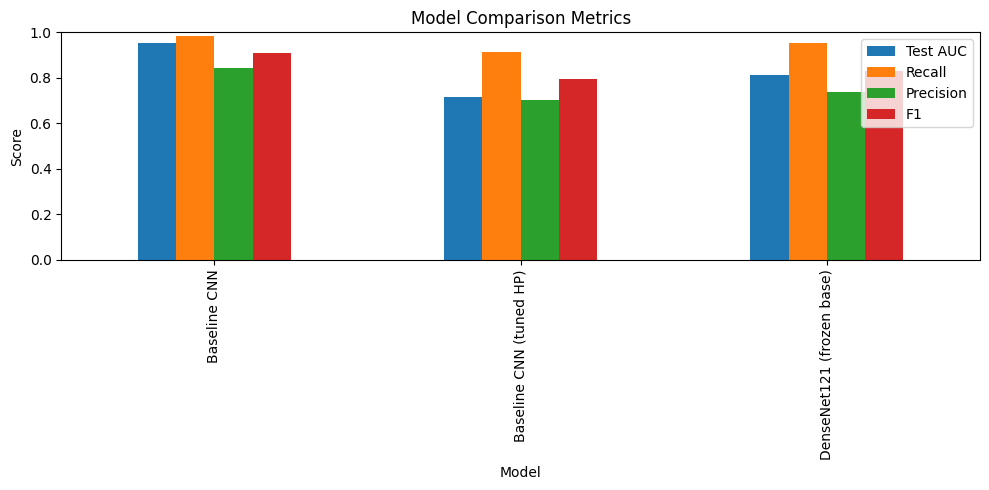

In [ ]:
records = []
for model_name, label in [
    ("baseline_cnn", "Baseline CNN"),
    ("baseline_cnn_tuned", "Baseline CNN (tuned HP)"),
    ("vgg16_frozen", "VGG16 (frozen base)")
]:
    meta = training_utils.load_model_meta(SAVE_DIR, model_name)
    if meta is None:
        continue
    m = meta["metrics"]
    records.append({
        "Model": label,
        "Test Acc": m.get("accuracy"),
        "Test AUC": m.get("auc"),
        "Precision": m.get("precision"),
        "Recall": m.get("recall"),
        "F1": m.get("f1"),
        "Best Threshold": meta.get("threshold"),
        "Trainable Params": meta.get("model_params", {}).get("trainable"),
    })

comparison_df = pd.DataFrame(records)
print(comparison_df)

# Bar chart for AUC / recall / precision / F1
if not comparison_df.empty:
    metric_cols = ["Test AUC", "Recall", "Precision", "F1"]
    ax = comparison_df.set_index("Model")[metric_cols].plot(kind="bar", figsize=(10, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Model Comparison Metrics")
    plt.tight_layout()
    plt.show()
